In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('./data.csv', encoding='latin1',header=None)


df.head()


,0,1
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [69]:
df.columns = ["label", "text"]
df.head()

,label,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [70]:
df.describe()


,label,text
count,4846,4846
unique,3,4838
top,neutral,Ahlstrom 's share is quoted on the NASDAQ OMX ...
freq,2879,2


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   4846 non-null   object
 1   text    4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [72]:
df.isnull().sum()

label    0
text     0
dtype: int64

In [73]:
df.columns

Index(['label', 'text'], dtype='object')

In [74]:
corpus = df["text"]

df.head()

,label,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


### Convert Text → TF-IDF Matrix

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=800,
    stop_words='english',
    max_df=0.85,
    min_df=5
)

X = vectorizer.fit_transform(corpus)


In [76]:
print(X.shape)


(4846, 800)


### Determine Optimal Number of Clusters

We don’t know how many topics exist.
So we let data guide us.

Use Silhouette Score

In [77]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

print(scores)


[0.005317464655228071, 0.013686009007634146, 0.012888218454312811, 0.014884908004527466, 0.01717517846376591, 0.016956136629113484, 0.017802232330725445, 0.020436760568089546, 0.02262957420819549]


Pick the k with highest score.(k=10 here)

That’s your natural topic count.

### Final Clustering

In [78]:
kmeans = KMeans(n_clusters=10, random_state=42)
df["cluster"] = kmeans.fit_predict(X)


### Discover Hidden Themes

In [79]:
import numpy as np

terms = vectorizer.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(10):
    print(f"\nCluster {i}:")
    top_words = centroids[i].argsort()[-10:]
    print([terms[index] for index in top_words])



Cluster 0:
['mn', 'services', 'includes', 'received', 'said', 'basware', 'finnish', 'eur', 'value', 'order']

Cluster 1:
['2010', 'ceo', 'year', 'new', 'according', 'oyj', 'business', 'finnish', 'said', 'company']

Cluster 2:
['oyj', 'year', 'liters', 'business', 'said', 'company', 'million', 'finnish', 'percent', 'group']

Cluster 3:
['sales', 'finnish', 'oyj', 'eur', '2006', 'profit', '2007', 'net', 'euro', 'mln']

Cluster 4:
['bank', 'industry', 'services', 'helsinki', 'sales', 'finnish', 'company', 'headquartered', 'market', 'finland']

Cluster 5:
['production', '000', 'companies', 'contract', 'finnish', 'year', 'services', 'business', 'said', 'new']

Cluster 6:
['company', 'voting', 'eps', 'rights', 'earnings', 'eur', 'eur0', 'capital', 'shares', 'share']

Cluster 7:
['network', 'devices', 'said', 'phones', 'siemens', 'networks', 'services', 'phone', 'mobile', 'nokia']

Cluster 8:
['net', 'totalled', 'loss', 'compared', 'corresponding', 'period', 'operating', 'profit', 'eur', 'mn

### Dendrogram Construction & Analysis

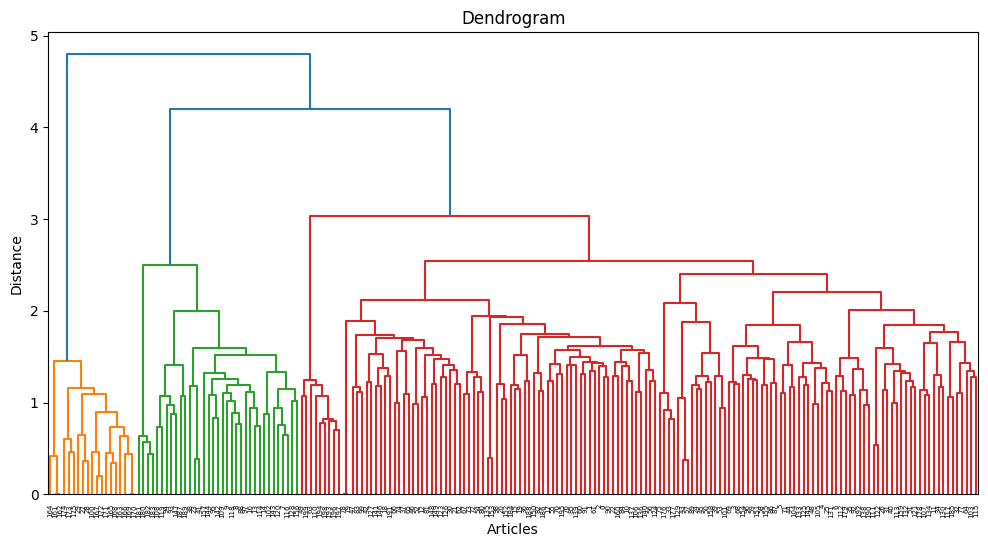

In [80]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Take subset (example: first 200 articles)
X_subset = X[:200].toarray()

plt.figure(figsize=(12,6))
dendrogram = sch.dendrogram(
    sch.linkage(X_subset, method='ward')
)
plt.title("Dendrogram")
plt.xlabel("Articles")
plt.ylabel("Distance")
plt.show()


### Apply Agglomerative Hierarchical Clustering

In [81]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=10,
    linkage='ward'
)

df_subset = df.iloc[:200].copy()
df_subset["cluster"] = model.fit_predict(X_subset)



### Validation Without Labels (Critical Thinking)

In [82]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_subset, df_subset["cluster"])
print("Silhouette Score:", score)


Silhouette Score: 0.0867052331643155
